<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/02_EDA_and_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Exploratory Data Analysis & Machine Learning Modelling
**Project:** Impact of Energy Efficiency on UK House Prices (2021-2025)  
**Description:** This notebook performs EDA on the cleaned dataset and executes the modelling strategy (OLS Baseline vs. Advanced ML Models).

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Montar o Drive
drive.mount('/content/drive')

# Definir o caminho para o ficheiro que guardámos no Passo 8 anterior
caminho_csv = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'

# Carregar os dados
df = pd.read_csv(caminho_csv)

# Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"✅ Dataset carregado com sucesso: {len(df)} linhas.")

Mounted at /content/drive
✅ Dataset carregado com sucesso: 547948 linhas.



## Step 2: Exploratory Data Analysis (EDA)
Nesta fase, realizamos a análise visual das variáveis principais para validar as distribuições estatísticas e identificar tendências preliminares. O foco recai sobre a variável dependente (`Price`) e a sua relação com a eficiência energética (`CURRENT_ENERGY_RATING`).


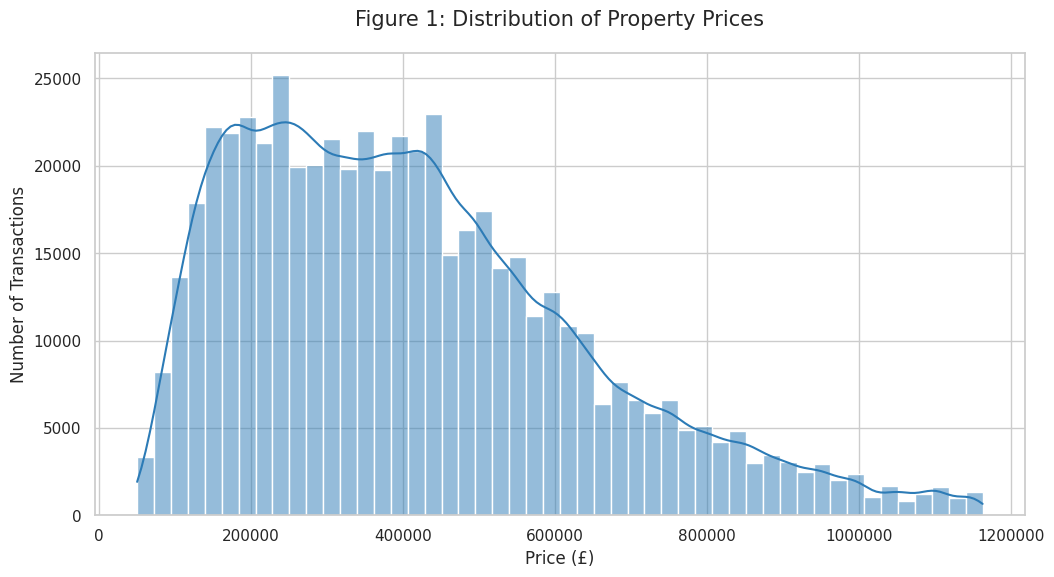

/tmp/ipython-input-1812/2538628842.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='CURRENT_ENERGY_RATING', y='Price', data=df_epc_price, palette=palete_cores)


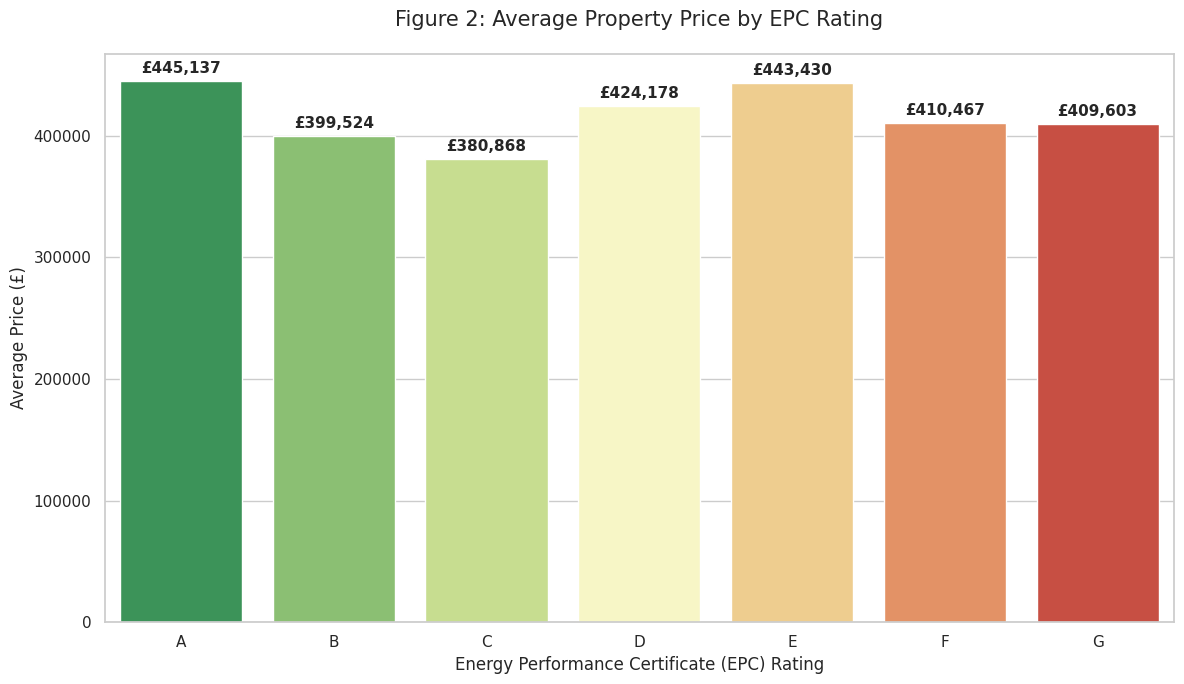

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir o estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 2.1 Distribuição da Variável Alvo (Price) ---
# Isto confirma que a limpeza IQR funcionou e mostra a "cara" do mercado
plt.figure(figsize=(12, 6))
sns.histplot(df['Price'], bins=50, kde=True, color='#2c7bb6')
plt.title('Figure 1: Distribution of Property Prices', fontsize=15, pad=20)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# --- 2.2 Evidência do Green Premium (Preço por EPC) ---
# Criar a ordem correta das categorias
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Agrupar e calcular a média
df_epc_price = df.groupby('CURRENT_ENERGY_RATING')['Price'].mean().reindex(epc_order).reset_index()

plt.figure(figsize=(12, 7))
# Usamos um gradiente de cor original RdYlGn_r: Verde (Eficiente) para Vermelho (Ineficiente)
palete_cores = sns.color_palette("RdYlGn_r", 7)
barplot = sns.barplot(x='CURRENT_ENERGY_RATING', y='Price', data=df_epc_price, palette=palete_cores)

plt.title('Figure 2: Average Property Price by EPC Rating', fontsize=15, pad=20)
plt.xlabel('Energy Performance Certificate (EPC) Rating', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)

# Adicionar os valores exatos por cima das barras
for p in barplot.patches:
    barplot.annotate(f"£{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 3: Correlation Analysis
Nesta fase, calculamos a matriz de correlação de Pearson para as variáveis contínuas. O objetivo é quantificar a força da relação linear entre o preço e os atributos físicos e espaciais do imóvel, identificando os preditores mais significativos para os modelos de regressão.


A gerar a matriz de correlação das variáveis numéricas...


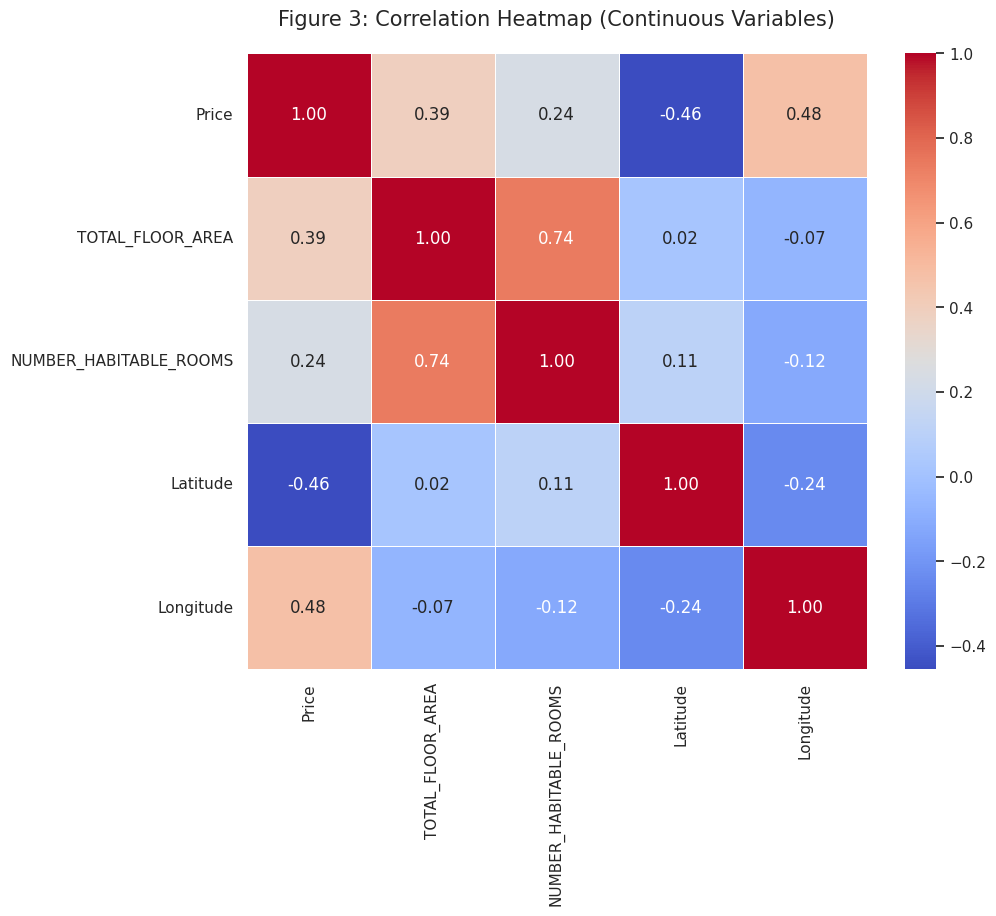

In [ ]:
# --- Step 3: Correlation Matrix ---

print("A gerar a matriz de correlação das variáveis numéricas...")

# Selecionar apenas as colunas numéricas para a correlação
cols_num = ['Price', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'Latitude', 'Longitude']
corr_matrix = df[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 3: Correlation Heatmap (Continuous Variables)', fontsize=15, pad=20)
plt.show()

### Step 3.1: Temporal and Spatial Analysis (Market Dynamics)

Para além das características intrínsecas dos imóveis, o "Green Premium" e os preços das casas são fortemente influenciados por fatores macroeconómicos ao longo do tempo e pela sua localização geográfica.

1. **Evolução Temporal (2021-2025):** Avaliamos a flutuação média dos preços ao longo dos meses para justificar a inclusão do `Year_of_Transfer` e `Month_of_Transfer` no modelo, capturando efeitos de inflação e choques de mercado pós-COVID.
2. **Distribuição Espacial:** Mapeamos as transações com base na `Latitude` e `Longitude`. Esta visualização prova a heterogeneidade espacial do mercado nas 3 regiões em estudo (Greater London, Greater Manchester, e Cornwall), justificando o uso de efeitos fixos espaciais (*Outcodes*) no modelo OLS e coordenadas diretas nos modelos de Machine Learning.

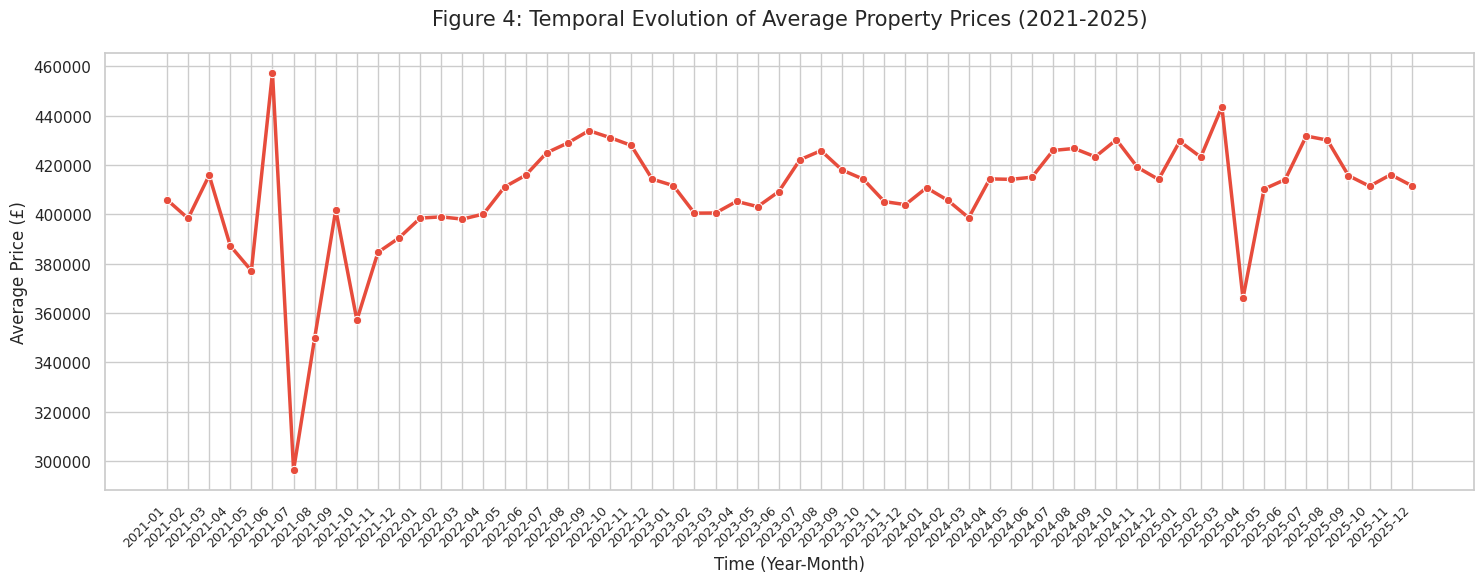

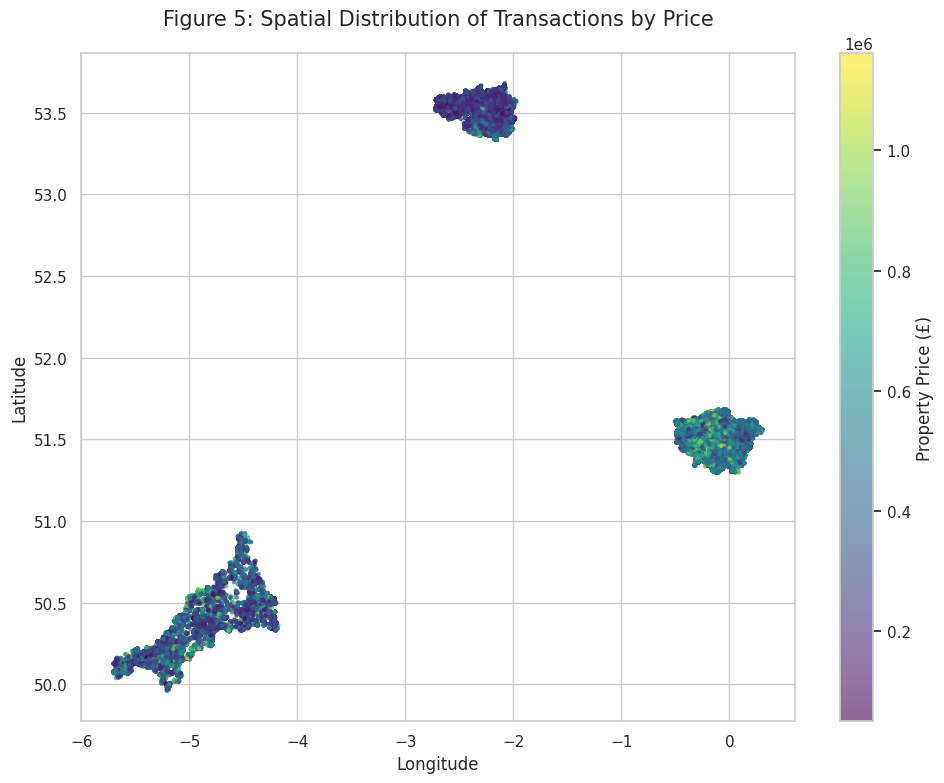

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Evolução Temporal dos Preços (Gráfico de Linhas) ---

# Criar uma coluna temporária 'Ano-Mês' apenas para facilitar a ordenação e visualização
df['YearMonth'] = df['Year_of_Transfer'].astype(str) + '-' + df['Month_of_Transfer'].astype(str).str.zfill(2)

# Agrupar para obter o preço médio por mês
df_temporal = df.groupby('YearMonth')['Price'].mean().reset_index()
df_temporal = df_temporal.sort_values('YearMonth')

plt.figure(figsize=(15, 6))
# Usamos group=1 para garantir que o Seaborn desenha uma linha contínua
sns.lineplot(x='YearMonth', y='Price', data=df_temporal, color='#e74c3c', linewidth=2.5, marker='o')

plt.title('Figure 4: Temporal Evolution of Average Property Prices (2021-2025)', fontsize=15, pad=20)
plt.xlabel('Time (Year-Month)', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)

# Rodar os rótulos do eixo X para não ficarem sobrepostos
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# --- 2. Distribuição Espacial (Mapa de Dispersão / Scatter Plot) ---

plt.figure(figsize=(10, 8))
# Desenhamos os pontos usando Latitude e Longitude, e colorimos pelo Preço
# Usamos s=5 (tamanho pequeno) e alpha=0.6 (transparência) porque temos ~500k pontos!
scatter = plt.scatter(x=df['Longitude'], y=df['Latitude'],
                      c=df['Price'], cmap='viridis',
                      s=5, alpha=0.6)

plt.title('Figure 5: Spatial Distribution of Transactions by Price', fontsize=15, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Adicionar a barra de cores ao lado
cbar = plt.colorbar(scatter)
cbar.set_label('Property Price (£)', fontsize=12)

plt.tight_layout()
plt.show()

# Limpar a coluna temporária para não interferir no Step 4
df = df.drop(columns=['YearMonth'])

### Step 3.2: Energy Efficiency Profiling (Regional and Structural)

Para compreender verdadeiramente o "Green Premium", é imperativo analisar como os certificados energéticos (EPC) se distribuem pelo parque habitacional.

1. **Perfil Energético Regional:** Comparamos a proporção de cada *rating* EPC entre Greater London, Greater Manchester e Cornwall. Esta análise revela assimetrias no parque habitacional (e.g., áreas mais rurais ou com menos nova construção tendem a ter uma prevalência maior de ratings baixos), justificando a necessidade de controlar o efeito espacial na modelação.
2. **Impacto da Idade da Construção no EPC:** Avaliamos a relação entre a `CONSTRUCTION_AGE_BAND` e o `CURRENT_ENERGY_RATING`. Como o Reino Unido possui um vasto número de propriedades históricas não adaptadas, espera-se uma forte correlação entre casas mais antigas e piores classificações energéticas, confirmando a idade como uma variável de controlo crítica.

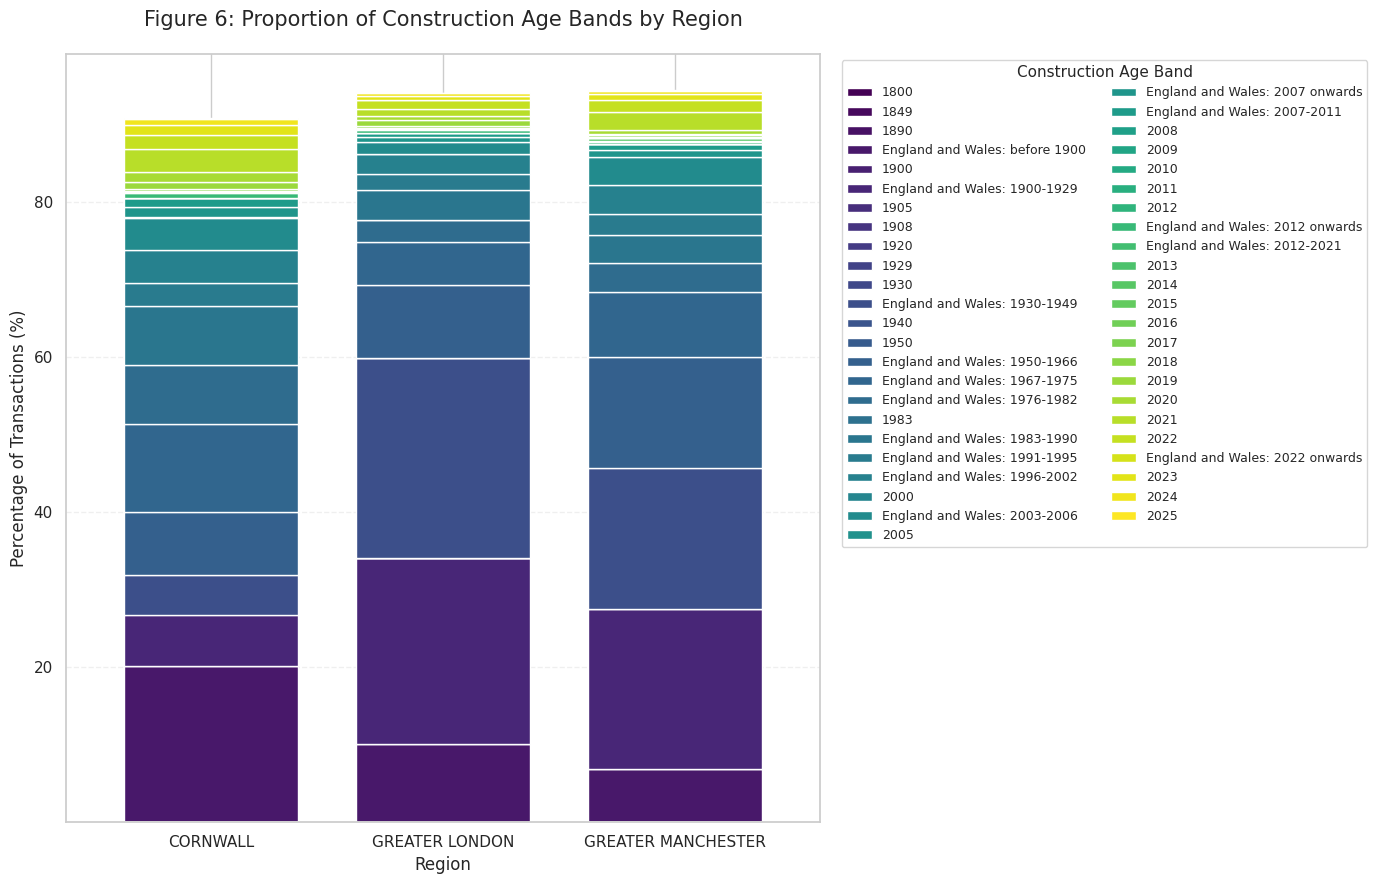

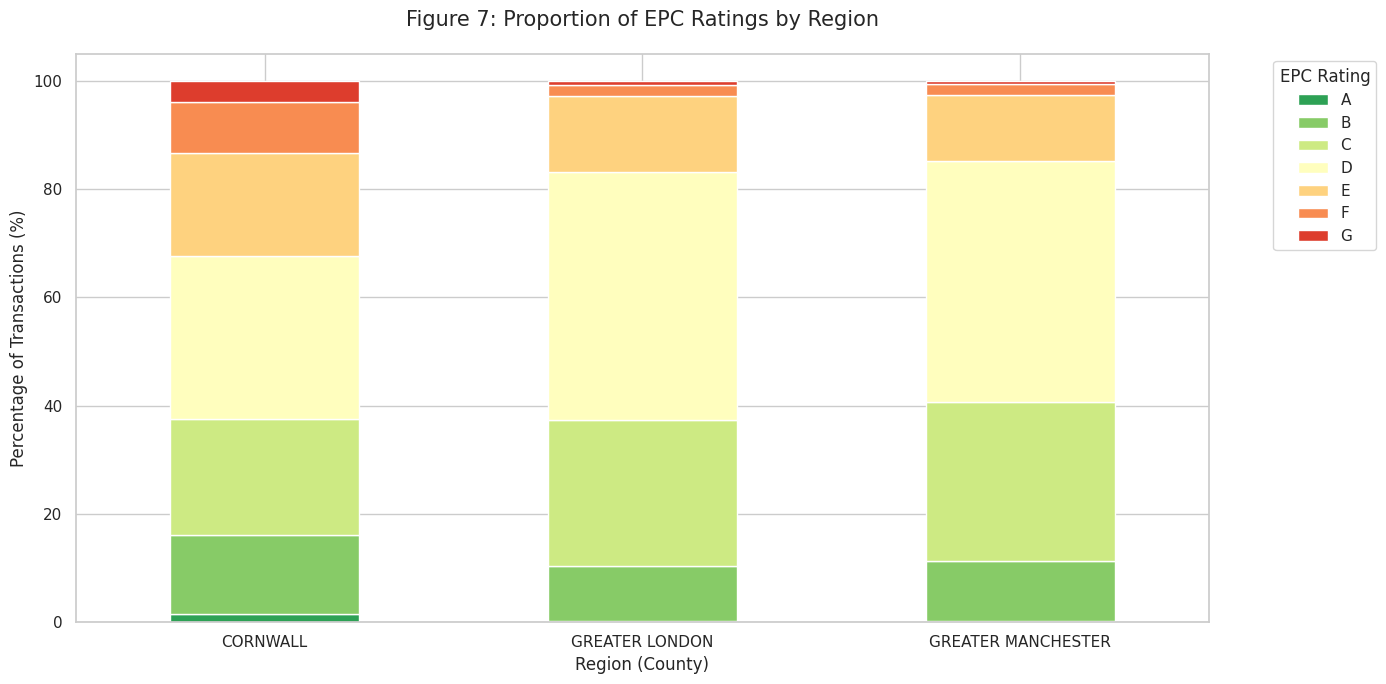

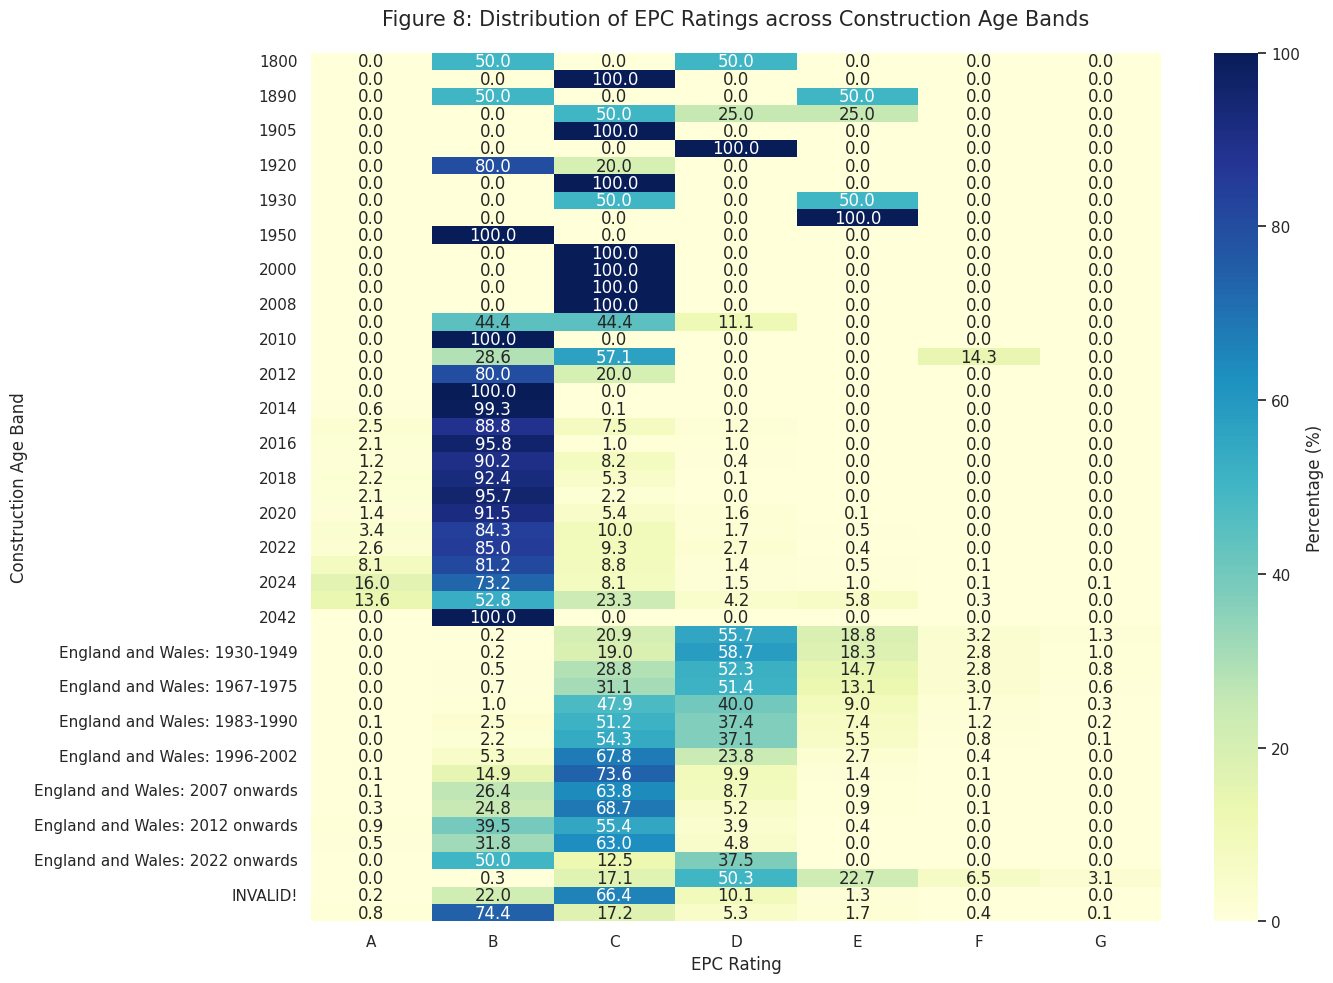

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# --- 1. Idade da Propriedade vs Região (VERSÃO CORRIGIDA E AJUSTADA) ---

# 1. Calcular percentagens
cross_age_region = pd.crosstab(
    df['County'],
    df['CONSTRUCTION_AGE_BAND'],
    normalize='index'
) * 100

bands_to_remove = ['2042', 'INVALID!', 'Unknown']
cross_age_region = cross_age_region.drop(
    columns=[col for col in bands_to_remove if col in cross_age_region.columns]
)

# 2. Função para extrair o ano inicial de cada banda (para ordenação perfeita)
def get_start_year(band):
    band = str(band).strip()

    if any(x in band.upper() for x in ['INVALID', 'UNKNOWN']):
        return 9999

    # "England and Wales: before 1900" → tratar como 1899
    if 'before 1900' in band.lower():
        return 1899

    # Extrair todos os anos de 4 dígitos e pegar o menor (início da banda)
    years = re.findall(r'\d{4}', band)
    if years:
        return int(min(years))

    # Banda com ano único (ex: "1800", "1930", etc.)
    if re.match(r'^\d{4}$', band):
        return int(band)

    return 9999  # segurança

# 3. Ordenar as bandas cronologicamente (mais antigo → mais recente)
age_bands = cross_age_region.columns.tolist()
sorted_age_bands = sorted(age_bands, key=get_start_year)

# Reordenar o DataFrame
cross_age_region = cross_age_region[sorted_age_bands]

# 4. Gráfico final (legenda agora cronológica + cores viridis perfeitas)
cross_age_region.plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    figsize=(14, 9),  # <-- AUMENTÁMOS A ALTURA DE 7 PARA 9
    edgecolor='white',
    width=0.75
)

plt.title('Figure 6: Proportion of Construction Age Bands by Region', fontsize=15, pad=20)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage of Transactions (%)', fontsize=12)

# Legenda limpa e ordenada (usando 2 colunas para poupar espaço vertical)
plt.legend(
    title='Construction Age Band',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=11,
    ncol=2  # <-- DIVIDIMOS EM 2 COLUNAS PARA NÃO DESCER TANTO
)

# Melhorar labels do eixo X
plt.xticks(
    ticks=range(len(cross_age_region.index)),
    labels=[x.replace(' (County)', '').replace('Region', '').strip()
            for x in cross_age_region.index],
    rotation=0
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# --- 2. Distribuição de Certificados EPC por Região ---
epc_colors = sns.color_palette("RdYlGn_r", 7)
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

cross_region = pd.crosstab(df['County'], df['CURRENT_ENERGY_RATING'], normalize='index') * 100
cross_region = cross_region.reindex(columns=epc_order)

cross_region.plot(kind='bar', stacked=True, color=epc_colors, figsize=(14, 7), edgecolor='white')

plt.title('Figure 7: Proportion of EPC Ratings by Region', fontsize=15, pad=20)
plt.xlabel('Region (County)', fontsize=12)
plt.ylabel('Percentage of Transactions (%)', fontsize=12)
plt.legend(title='EPC Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --- 3. EPC vs Idade da Propriedade (Heatmap Original Melhorado) ---
plt.figure(figsize=(14, 10))

cross_age = pd.crosstab(df['CONSTRUCTION_AGE_BAND'], df['CURRENT_ENERGY_RATING'], normalize='index') * 100
cross_age = cross_age.reindex(columns=epc_order)

sns.heatmap(cross_age, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'})

plt.title('Figure 8: Distribution of EPC Ratings across Construction Age Bands', fontsize=15, pad=20)
plt.xlabel('EPC Rating', fontsize=12)
plt.ylabel('Construction Age Band', fontsize=12)

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 4: Data Transformation and Train-Test Split

Nesta etapa, preparamos os dados categóricos para os algoritmos de modelação matemática e dividimos o dataset para garantir uma avaliação justa dos modelos (evitando *data leakage*).

1. **Ordinal Encoding:** A variável `CURRENT_ENERGY_RATING` é convertida numa escala numérica ordinal (A=7 a G=1), refletindo a hierarquia da eficiência energética.
2. **One-Hot Encoding:** As variáveis nominais (como `Property_Type`, `Postcode_Outcode`, etc.) são transformadas em variáveis binárias (0 e 1). Utilizamos `drop_first=True` para evitar a *Dummy Variable Trap* (multicolinearidade perfeita), o que é um requisito estrito para o modelo de Regressão Linear (OLS) que servirá de *baseline*.
3. **Train-Test Split:** O dataset é dividido em 80% para treino dos modelos e 20% para teste (validação final). O parâmetro `random_state=42` é fixado em conformidade com as boas práticas de reprodutibilidade científica (Metodologia CRISP-ML).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("--- Step 4: Data Transformation and Train-Test Split ---")

# 1. Ordinal Encoding para CURRENT_ENERGY_RATING
# A=7 (Mais Eficiente) até G=1 (Menos Eficiente)
epc_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(epc_mapping)

print("✅ Ordinal Encoding concluído.")

# 2. One-Hot Encoding
# Lista das variáveis nominais a converter
categorical_cols = [
    'Property_Type',
    'Old_New',
    'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND',
    'Postcode_Outcode',
    'Year_of_Transfer',
    'Month_of_Transfer'
]

# get_dummies com drop_first=True para evitar a "Dummy Variable Trap" (crítico para o baseline OLS)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# As variáveis geradas pelo get_dummies vêm como booleanos (True/False).
# Para garantir compatibilidade total com os algoritmos de ML, vamos convertê-las para 1 e 0.
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

print(f"✅ One-Hot Encoding concluído. O dataset passou de {df.shape[1]} para {df_encoded.shape[1]} colunas.")

# 3. Train-Test Split (80% / 20%)
# Definir Features (X) e Target (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# Divisão dos dados com random_state=42 para total reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("✅ Data Splitting concluído.")
print(f"Tamanho do Treino (Train): {X_train.shape[0]} transações.")
print(f"Tamanho do Teste (Test): {X_test.shape[0]} transações.")

# Inspecionar as primeiras linhas do X_train para confirmar
display(X_train.head(3))